# Expected Threat (xT) Analysis

This notebook analyzes football event data to estimate where dangerous actions are most likely to happen on the pitch.

In simple terms, it follows this workflow:
1. Load competition and match information from the project data folder.
2. Select one competition and season.
3. Read all match events and convert them into a structured table.
4. Divide the pitch into zones and calculate how often actions start and end in each zone.
5. Build an Expected Threat model and visualize the results as a pitch map.

The goal is to understand which areas of the pitch create the greatest attacking value.


In [1]:
from pathlib import Path
import json
import pandas as pd

DATA_DIR = Path("archive/data")

competitions = pd.read_json(DATA_DIR / "competitions.json")
competitions.head()

c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [2]:
rows = []

for _, row in competitions.iterrows():
    competition_id = row["competition_id"]
    season_id = row["season_id"]
    match_file = DATA_DIR / "matches" / str(competition_id) / f"{season_id}.json"
    
    if match_file.exists():
        with open(match_file, "r", encoding="utf-8") as f:
            matches = json.load(f)
        
        teams = set()
        for m in matches:
            teams.add(m["home_team"]["home_team_name"])
            teams.add(m["away_team"]["away_team_name"])
        
        rows.append({
            "competition_id": competition_id,
            "season_id": season_id,
            "competition_name": row["competition_name"],
            "season_name": row["season_name"],
            "country_name": row["country_name"],
            "n_matches": len(matches),
            "n_teams": len(teams)
        })

season_summary = pd.DataFrame(rows)
season_summary.sort_values("n_matches", ascending=False).head(10)

,competition_id,season_id,competition_name,season_name,country_name,n_matches,n_teams
70,12,27,Serie A,2015/2016,Italy,380,20
45,11,27,La Liga,2015/2016,Spain,380,20
68,2,27,Premier League,2015/2016,England,380,20
63,7,27,Ligue 1,2015/2016,France,377,20
58,182,281,Liga F,2023/2024,Spain,240,16
66,49,107,NWSL,2023,United States of America,137,12
38,135,281,Frauen Bundesliga,2023/2024,Germany,132,12
25,37,281,FA Women's Super League,2023/2024,England,132,12
26,37,90,FA Women's Super League,2020/2021,England,131,12
72,131,281,Serie A Women,2023/2024,Italy,130,10


In [3]:
COMPETITION_ID = '11'
SEASON_ID = '27'

As it indicated, 15/16 season Serie A and La Liga had the most matches and teams. We choose La Liga as our researching object.

In [4]:
match_file = DATA_DIR / "matches" / str(COMPETITION_ID) / f"{SEASON_ID}.json"

with open(match_file, "r", encoding="utf-8") as f:
    matches = json.load(f)

match_ids = [m["match_id"] for m in matches]
len(match_ids)

380

This block loads all event details for the selected matches.
It defines a helper function to read the event JSON for each match, tags each event with its match ID, and then combines every match’s events into one big list.
The final `len(all_events)` shows how many event records were loaded for analysis.


In [5]:
def load_match_events(match_id):
    event_file = DATA_DIR / "events" / f"{match_id}.json"
    with open(event_file, "r", encoding="utf-8") as f:
        events = json.load(f)
    
    for e in events:
        e["match_id"] = match_id
    
    return events


all_events = []

for match_id in match_ids:
    event_file = DATA_DIR / "events" / f"{match_id}.json"
    if event_file.exists():
        all_events.extend(load_match_events(match_id))
    else:
        print(f"Missing event file: {match_id}")

len(all_events)

1295354

In [6]:
import numpy as np
import pandas as pd

PITCH_LENGTH = 120
PITCH_WIDTH = 80

def parse_events_for_xt(events):
    rows = []

    for e in events:
        event_type = e["type"]["name"]
        location = e.get("location", None)

        if location is None:
            continue

        x, y = location[0], location[1]

        base = {
            "match_id": e["match_id"],
            "event_id": e["id"],
            "period": e["period"],
            "minute": e["minute"],
            "second": e["second"],
            "team": e["team"]["name"] if "team" in e else None,
            "player": e["player"]["name"] if "player" in e else None,
            "event_type": event_type,
            "start_x": x,
            "start_y": y,
            "end_x": np.nan,
            "end_y": np.nan,
            "is_goal": False,
            "is_success": False,
        }

        if event_type == "Shot":
            shot = e.get("shot", {})
            outcome = shot.get("outcome", {}).get("name", None)

            base["action_type"] = "shot"
            base["is_goal"] = outcome == "Goal"
            base["is_success"] = True

            rows.append(base)

        elif event_type == "Pass":
            pass_data = e.get("pass", {})
            end_location = pass_data.get("end_location", None)

            if end_location is None:
                continue

            outcome = pass_data.get("outcome", None)

            base["action_type"] = "move"
            base["move_type"] = "pass"
            base["end_x"] = end_location[0]
            base["end_y"] = end_location[1]

            # StatsBomb 中，成功传球通常没有 outcome 字段
            base["is_success"] = outcome is None

            rows.append(base)

        elif event_type == "Carry":
            carry = e.get("carry", {})
            end_location = carry.get("end_location", None)

            if end_location is None:
                continue

            base["action_type"] = "move"
            base["move_type"] = "carry"
            base["end_x"] = end_location[0]
            base["end_y"] = end_location[1]
            base["is_success"] = True

            rows.append(base)

    return pd.DataFrame(rows)


df_events = parse_events_for_xt(all_events)
df_events.head()

,match_id,event_id,period,minute,second,team,player,event_type,start_x,start_y,end_x,end_y,is_goal,is_success,action_type,move_type
0,3825739,a7bc8dba-ace5-4608-bfa0-ce8e6d24f17e,1,0,1,Sporting Gijón,Miguel Ángel Guerrero Martín,Pass,61.0,40.1,59.3,42.3,False,True,move,pass
1,3825739,d7e4b179-4074-49a1-9fd7-e7a392ba630c,1,0,1,Sporting Gijón,Alen Halilović,Carry,59.3,42.3,59.5,41.5,False,True,move,carry
2,3825739,bf01fecb-58ab-4dd2-82a7-0c13c89b687e,1,0,1,Sporting Gijón,Alen Halilović,Pass,59.5,41.5,47.7,43.8,False,True,move,pass
3,3825739,795f372e-abfc-4144-a378-0bfe6373ff62,1,0,3,Sporting Gijón,Ignacio Cases Mora,Pass,51.2,42.7,75.5,15.4,False,True,move,pass
4,3825739,63510231-73aa-4992-a601-18e742e69d8d,1,0,6,Sporting Gijón,Alejandro Menéndez Díez,Carry,75.5,15.4,74.7,15.1,False,True,move,carry


In [7]:
df_events["event_type"].value_counts()
df_events[df_events["action_type"] == "shot"]["start_x"].describe()

count    9168.000000
mean      103.808879
std         8.670434
min        50.300000
25%        97.600000
50%       105.300000
75%       110.600000
max       120.000000
Name: start_x, dtype: float64

In [8]:
L = 16
W = 12

def assign_zone(x, y, l=L, w=W):
    x_bin = np.floor(x / PITCH_LENGTH * l).astype(int)
    y_bin = np.floor(y / PITCH_WIDTH * w).astype(int)

    x_bin = np.clip(x_bin, 0, l - 1)
    y_bin = np.clip(y_bin, 0, w - 1)

    return y_bin * l + x_bin


df_events["start_zone"] = assign_zone(df_events["start_x"], df_events["start_y"])

move_mask = df_events["action_type"].eq("move")
df_events.loc[move_mask, "end_zone"] = assign_zone(
    df_events.loc[move_mask, "end_x"],
    df_events.loc[move_mask, "end_y"]
)

df_events.head()

,match_id,event_id,period,minute,second,team,player,event_type,start_x,start_y,end_x,end_y,is_goal,is_success,action_type,move_type,start_zone,end_zone
0,3825739,a7bc8dba-ace5-4608-bfa0-ce8e6d24f17e,1,0,1,Sporting Gijón,Miguel Ángel Guerrero Martín,Pass,61.0,40.1,59.3,42.3,False,True,move,pass,104,103.0
1,3825739,d7e4b179-4074-49a1-9fd7-e7a392ba630c,1,0,1,Sporting Gijón,Alen Halilović,Carry,59.3,42.3,59.5,41.5,False,True,move,carry,103,103.0
2,3825739,bf01fecb-58ab-4dd2-82a7-0c13c89b687e,1,0,1,Sporting Gijón,Alen Halilović,Pass,59.5,41.5,47.7,43.8,False,True,move,pass,103,102.0
3,3825739,795f372e-abfc-4144-a378-0bfe6373ff62,1,0,3,Sporting Gijón,Ignacio Cases Mora,Pass,51.2,42.7,75.5,15.4,False,True,move,pass,102,42.0
4,3825739,63510231-73aa-4992-a601-18e742e69d8d,1,0,6,Sporting Gijón,Alejandro Menéndez Díez,Carry,75.5,15.4,74.7,15.1,False,True,move,carry,42,41.0


In [9]:
shots = df_events[df_events["action_type"] == "shot"].copy()

successful_moves = df_events[
    (df_events["action_type"] == "move") &
    (df_events["is_success"] == True)
].copy()

In [10]:
n_zones = L * W

shot_counts = shots.groupby("start_zone").size().reindex(range(n_zones), fill_value=0)
goal_counts = shots[shots["is_goal"]].groupby("start_zone").size().reindex(range(n_zones), fill_value=0)

move_counts = successful_moves.groupby("start_zone").size().reindex(range(n_zones), fill_value=0)

total_actions = shot_counts + move_counts

In [11]:
shot_prob = np.divide(
    shot_counts,
    total_actions,
    out=np.zeros(n_zones, dtype=float),
    where=total_actions > 0
)

move_prob = np.divide(
    move_counts,
    total_actions,
    out=np.zeros(n_zones, dtype=float),
    where=total_actions > 0
)

goal_prob = np.divide(
    goal_counts,
    shot_counts,
    out=np.zeros(n_zones, dtype=float),
    where=shot_counts > 0
)

In [12]:
transition_matrix = np.zeros((n_zones, n_zones))

for _, row in successful_moves.iterrows():
    start_zone = int(row["start_zone"])
    end_zone = int(row["end_zone"])
    transition_matrix[start_zone, end_zone] += 1

row_sums = transition_matrix.sum(axis=1, keepdims=True)

transition_matrix = np.divide(
    transition_matrix,
    row_sums,
    out=np.zeros_like(transition_matrix),
    where=row_sums > 0
)

In [13]:
shot_prob = shot_prob.to_numpy()
move_prob = move_prob.to_numpy()
goal_prob = goal_prob.to_numpy()

In [14]:
xt = np.zeros(n_zones)

for i in range(100):
    new_xt = shot_prob * goal_prob + move_prob * transition_matrix.dot(xt)
    
    delta = np.max(np.abs(new_xt - xt))
    xt = new_xt
    
    if delta < 1e-6:
        print(f"Converged after {i + 1} iterations")
        break

xt_grid = xt.reshape(W, L)
xt_grid

array([[0.11457126, 0.11460578, 0.11463334, 0.11466431, 0.11471865,
        0.11483876, 0.11496762, 0.11518635, 0.11556675, 0.11604512,
        0.11686378, 0.11873605, 0.12120205, 0.12586414, 0.13149122,
        0.15424623],
       [0.114576  , 0.11454674, 0.11459697, 0.1146677 , 0.1147017 ,
        0.11479184, 0.11482062, 0.11501164, 0.11519432, 0.11546569,
        0.1158653 , 0.11745517, 0.11978865, 0.12422858, 0.13200141,
        0.14152131],
       [0.11457432, 0.11455533, 0.1146118 , 0.11464704, 0.11472795,
        0.11476406, 0.11475266, 0.11489843, 0.11479792, 0.11476107,
        0.11493699, 0.11415153, 0.11489536, 0.11667175, 0.1292532 ,
        0.14133665],
       [0.11459609, 0.11464741, 0.11465254, 0.11468424, 0.11470601,
        0.11478359, 0.11475151, 0.11467041, 0.11445409, 0.11367547,
        0.11259093, 0.1091772 , 0.10184239, 0.10323731, 0.11224419,
        0.14141114],
       [0.11463667, 0.11464703, 0.11465589, 0.1146163 , 0.11468635,
        0.11473049, 0.11468659, 

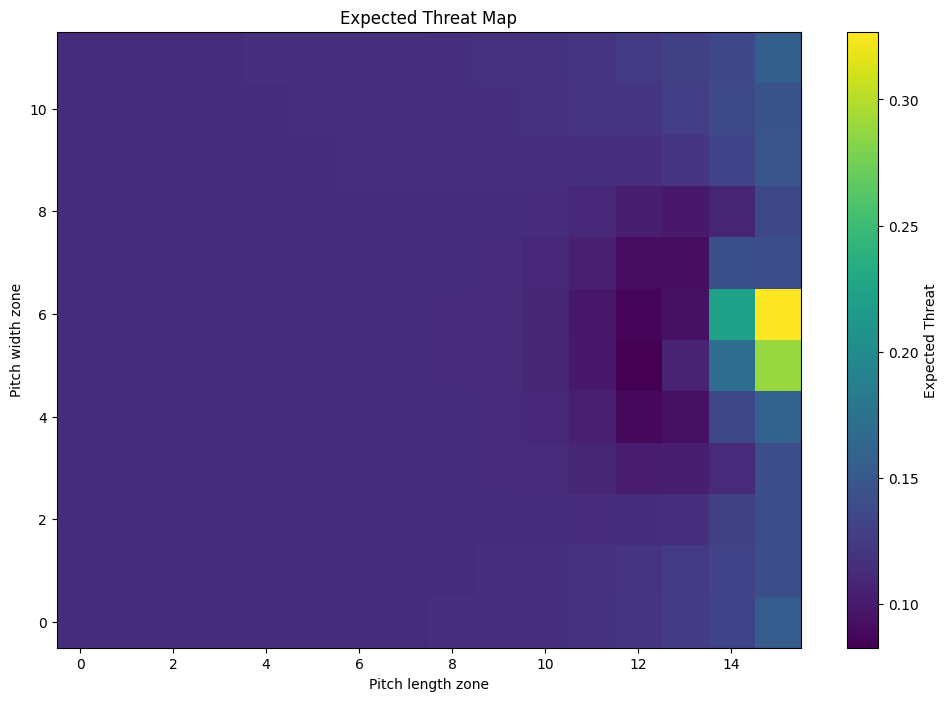

In [27]:
import matplotlib.pyplot as plt

# Ensure xT values are strictly positive for display (avoid negatives/zeros in Excel and plots)
xt_grid = np.clip(xt_grid, 1e-6, None)

plt.figure(figsize=(12, 8))
plt.imshow(xt_grid, origin="lower", aspect="auto")
plt.colorbar(label="Expected Threat")
plt.title("Expected Threat Map")
plt.xlabel("Pitch length zone")
plt.ylabel("Pitch width zone")
plt.show()

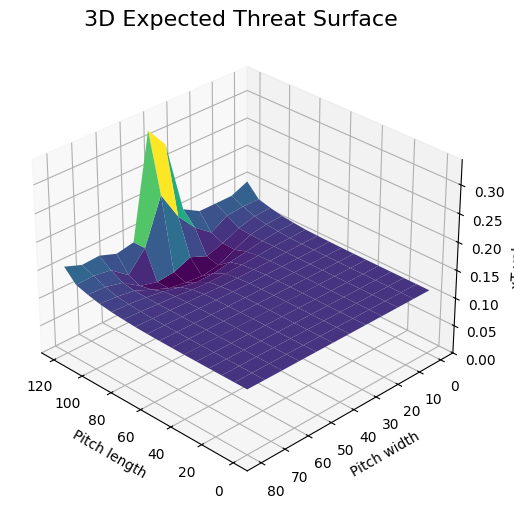

In [34]:
# 3D Expected Threat Surface (single global view)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")

# ensure xt_grid has no negative values
xt_grid = np.clip(xt_grid, 1e-6, None)

X = np.linspace(0, 120, L)
Y = np.linspace(0, 80, W)
X_grid, Y_grid = np.meshgrid(X, Y)

surf = ax.plot_surface(
    X_grid,
    Y_grid,
    xt_grid,
    cmap="viridis",
    edgecolor="none",
    antialiased=True,
    rcount=50,
    ccount=50
)

# set z limits so the floor is zero (no negative z)
ax.set_zlim(0, float(xt_grid.max()) * 1.05)

# view from lower-left corner of the pitch (approx):
# an azimuth around 135 and modest elevation places the camera near (0,0)
ax.view_init(elev=30, azim=135)

ax.set_title("3D Expected Threat Surface", fontsize=16)
ax.set_xlabel("Pitch length")
ax.set_ylabel("Pitch width")
ax.set_zlabel("xT value")
plt.show()


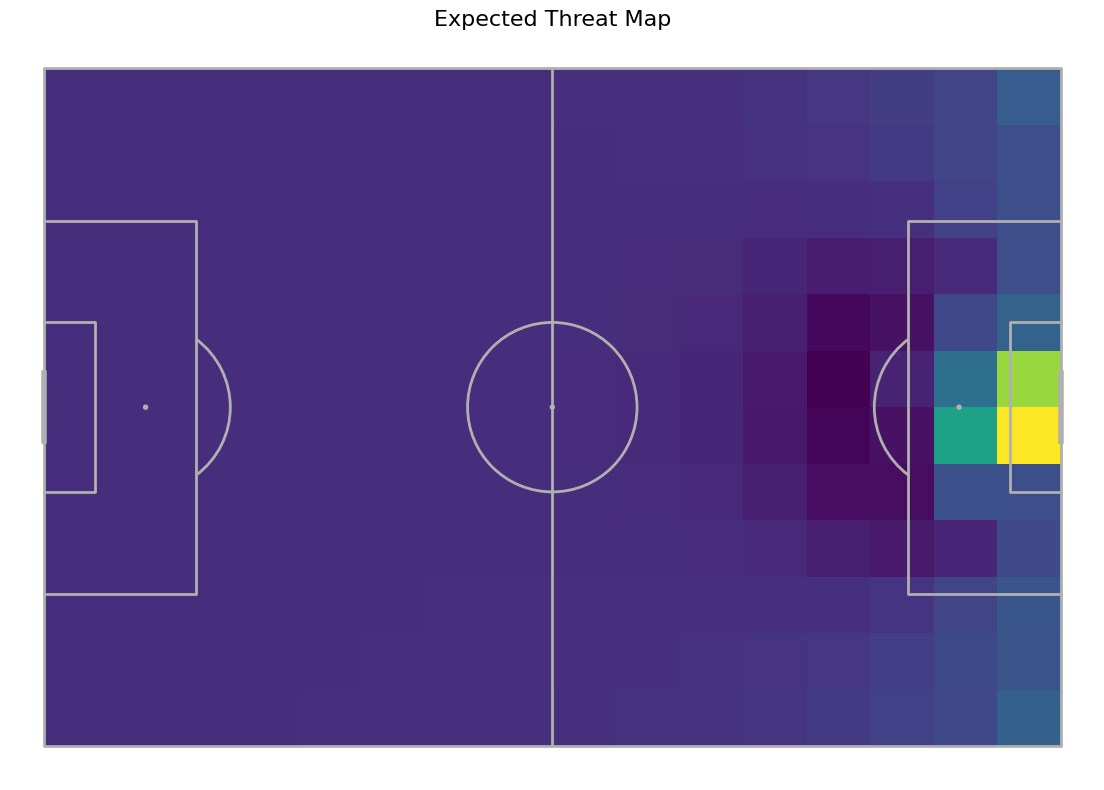

In [35]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_length=120,
    pitch_width=80,
    line_zorder=2
)

fig, ax = pitch.draw(figsize=(12, 8))

pitch.heatmap(
    {
        "statistic": xt_grid,
        "x_grid": np.linspace(0, 120, L + 1),
        "y_grid": np.linspace(0, 80, W + 1)
    },
    ax=ax,
    cmap="viridis"
)

ax.set_title("Expected Threat Map", fontsize=16)
plt.show()

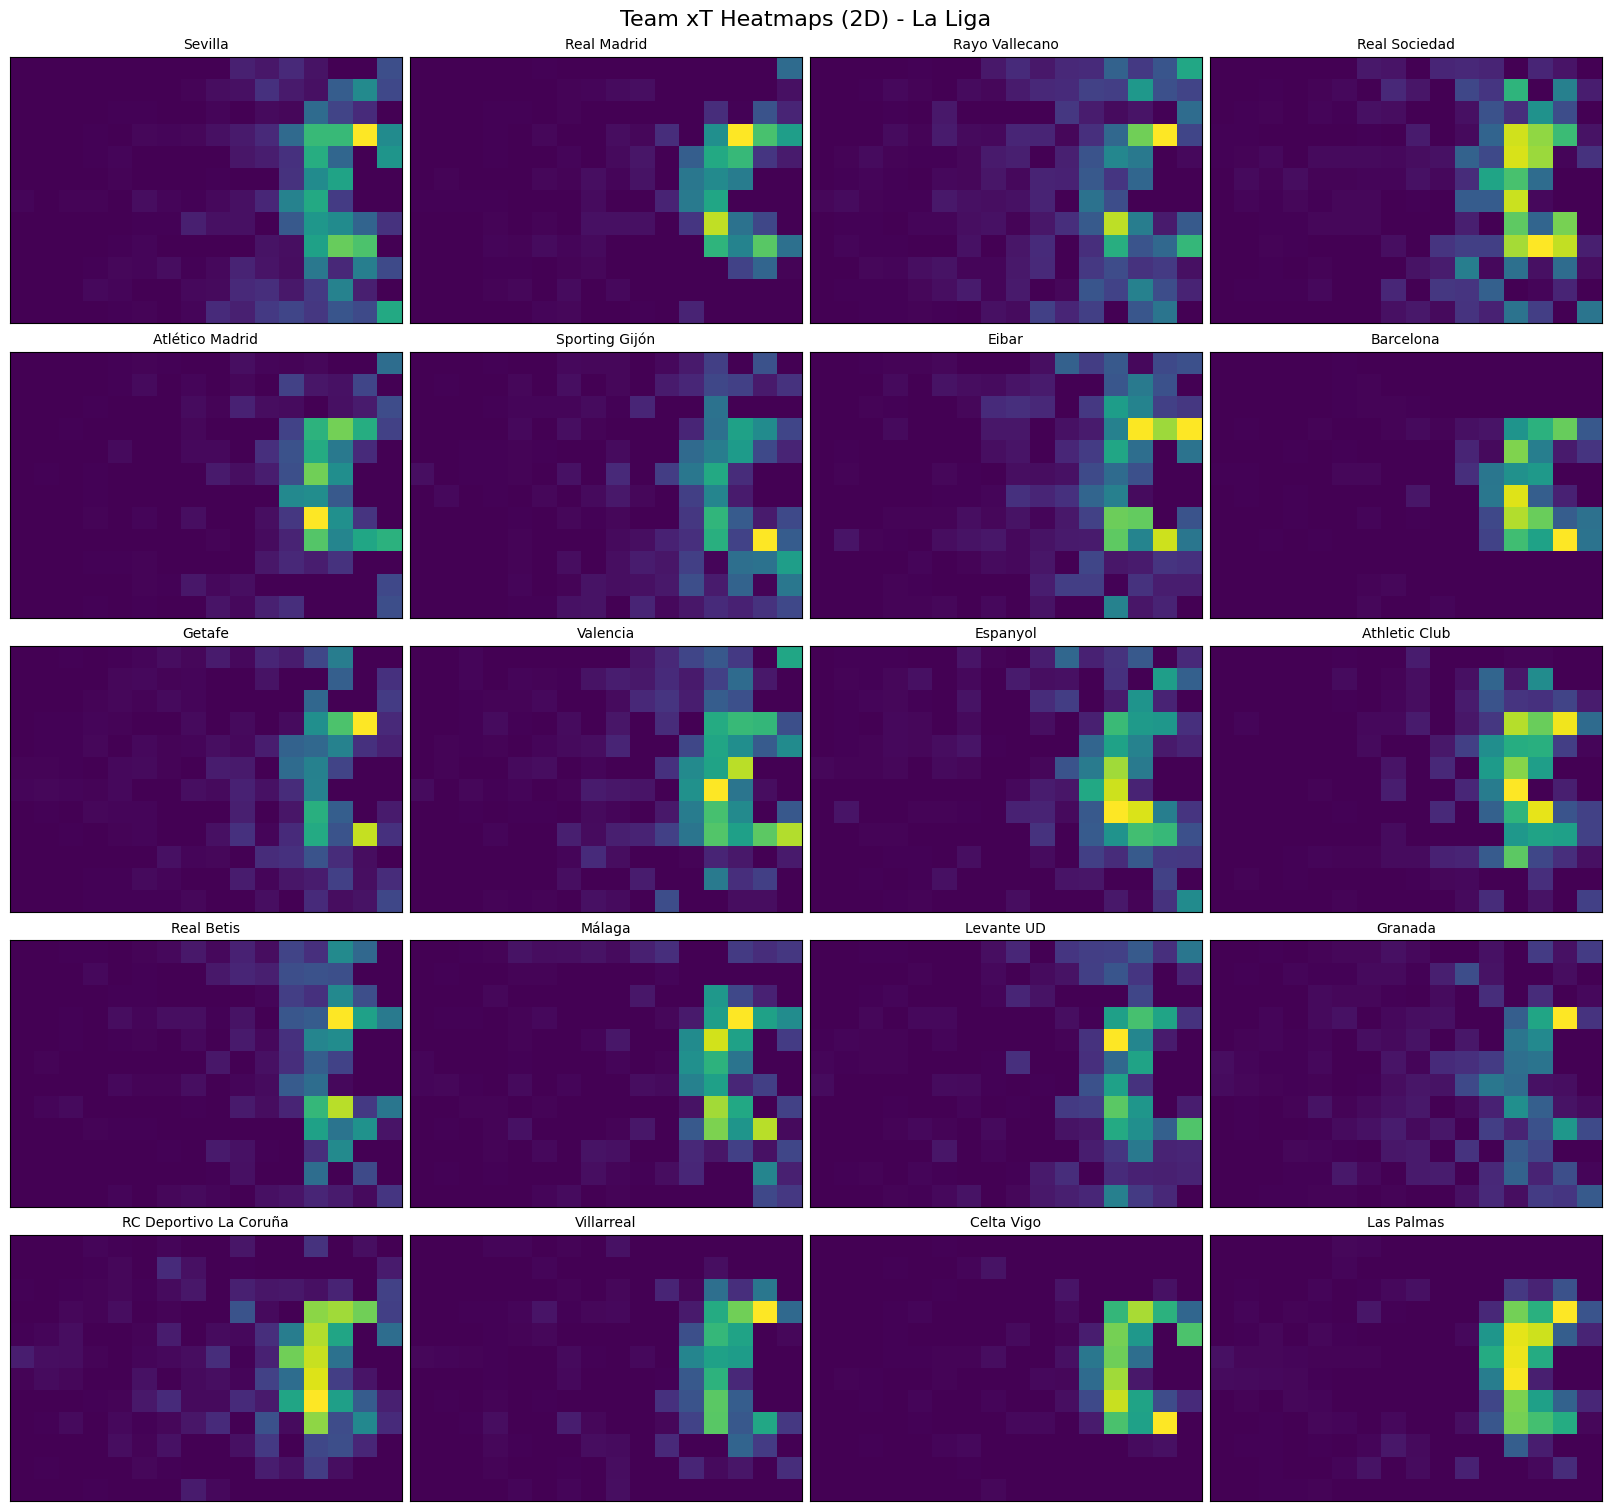

In [36]:
# 2D Team xT Heatmaps on Pitch (La Liga)

from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Recompute team zone xT in case it's not in memory
team_zone_xt = (
    successful_moves
    .groupby(["team", "start_zone"])["xT_value"]
    .sum()
    .unstack(fill_value=0)
)

teams_sorted = team_zone_xt.sum(axis=1).sort_values(ascending=False).index.tolist()
n_teams = len(teams_sorted)
cols = 4
rows = int(np.ceil(n_teams / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), constrained_layout=True)

for idx, team in enumerate(teams_sorted):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    grid = team_zone_xt.loc[team].reindex(range(n_zones), fill_value=0).values.reshape(W, L)
    grid = np.clip(grid, 1e-6, None)  # ensure strictly positive values

    pitch.heatmap(
        {
            "statistic": grid,
            "x_grid": np.linspace(0, 120, L + 1),
            "y_grid": np.linspace(0, 80, W + 1)
        },
        ax=ax,
        cmap="viridis"
    )

    ax.set_title(team, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# turn off empty subplots
for idx in range(n_teams, rows * cols):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis("off")

fig.suptitle("Team xT Heatmaps (2D) - La Liga", fontsize=16)
plt.show()


# Team 3D xT Surfaces

This section creates a separate 3D expected-threat surface for every team in the season. Each surface uses zone xT values to build a 3D pitch surface that shows attack value by pitch location.

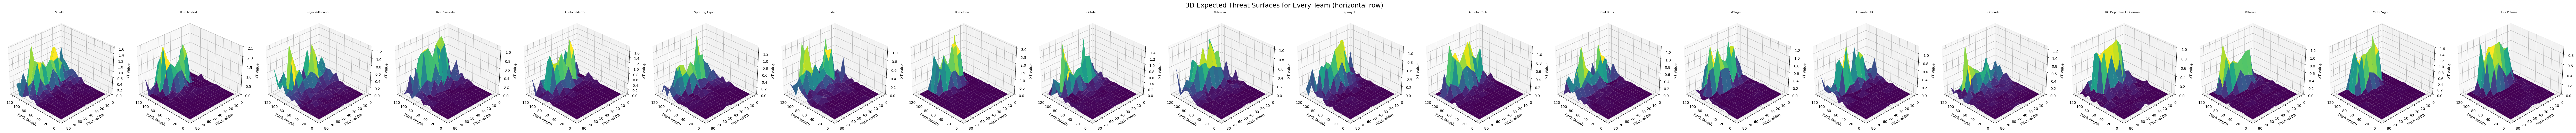

In [ ]:
team_zone_xt = (
    successful_moves
    .groupby(["team", "start_zone"])["xT_value"]
    .sum()
    .unstack(fill_value=0)
)

teams_sorted = team_zone_xt.sum(axis=1).sort_values(ascending=False).index.tolist()
n_teams = len(teams_sorted)
cols = 4
rows = int(np.ceil(n_teams / cols))

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(5 * cols, 5 * rows), constrained_layout=True)

X = np.linspace(0, 120, L)
Y = np.linspace(0, 80, W)
X_grid, Y_grid = np.meshgrid(X, Y)

for idx, team in enumerate(teams_sorted):
    ax = fig.add_subplot(rows, cols, idx + 1, projection="3d")
    grid = team_zone_xt.loc[team].reindex(range(n_zones), fill_value=0).values.reshape(W, L)
    grid = np.clip(grid, 1e-6, None)

    ax.plot_surface(
        X_grid,
        Y_grid,
        grid,
        cmap="viridis",
        edgecolor="none",
        antialiased=True,
        rcount=50,
        ccount=50
    )

    ax.set_title(team, fontsize=8)
    ax.set_xlabel("Pitch length")
    ax.set_ylabel("Pitch width")
    ax.set_zlabel("xT value")
    ax.set_zlim(0, float(grid.max()) * 1.05)

    # view from lower-left corner
    ax.view_init(elev=30, azim=135)

fig.suptitle("3D Expected Threat Surfaces for Every Team", fontsize=18)
plt.show()


In [23]:
successful_moves["start_zone"] = successful_moves["start_zone"].astype(int)
successful_moves["end_zone"] = successful_moves["end_zone"].astype(int)

successful_moves["xT_start"] = successful_moves["start_zone"].map(lambda z: xt[z])
successful_moves["xT_end"] = successful_moves["end_zone"].map(lambda z: xt[z])
successful_moves["xT_value"] = successful_moves["xT_end"] - successful_moves["xT_start"]

successful_moves[
    ["match_id", "team", "player", "move_type", "start_x", "start_y", "end_x", "end_y", "xT_value"]
].head()

,match_id,team,player,move_type,start_x,start_y,end_x,end_y,xT_value
0,3825739,Sporting Gijón,Miguel Ángel Guerrero Martín,pass,61.0,40.1,59.3,42.3,0.000459
1,3825739,Sporting Gijón,Alen Halilović,carry,59.3,42.3,59.5,41.5,0.000000
2,3825739,Sporting Gijón,Alen Halilović,pass,59.5,41.5,47.7,43.8,0.000089
3,3825739,Sporting Gijón,Ignacio Cases Mora,pass,51.2,42.7,75.5,15.4,0.000203
4,3825739,Sporting Gijón,Alejandro Menéndez Díez,carry,75.5,15.4,74.7,15.1,-0.000176


In [20]:
successful_moves["positive_xT"] = successful_moves["xT_value"].clip(lower=0)

player_ranking = (
    successful_moves
    .groupby("player", as_index=False)
    .agg(
        net_xT=("xT_value", "sum"),
        positive_xT=("positive_xT", "sum"),
        actions=("xT_value", "count"),
        xT_per_action=("xT_value", "mean")
    )
    .sort_values("positive_xT", ascending=False)
)

player_ranking.head(20)

,player,net_xT,positive_xT,actions,xT_per_action
382,Neymar da Silva Santos Junior,1.629529,14.312568,3705,0.000440
320,Lionel Andrés Messi Cuccittini,3.496958,13.709141,3627,0.000964
327,Luis Alberto Suárez Díaz,5.206445,10.097042,1727,0.003015
153,Fabián Ariel Orellana Valenzuela,1.928086,8.637205,3032,0.000636
397,Pablo Sarabia García,4.650598,8.468246,1980,0.002349
273,Jorge Resurrección Merodio,3.396392,8.192714,3424,0.000992
345,Marco Asensio Willemsen,3.720762,8.144926,2186,0.001702
261,Jonathan Viera Ramos,1.206315,7.906518,3461,0.000349
428,Roberto Trashorras Gayoso,4.292264,7.886854,4215,0.001018
38,Andrés Iniesta Luján,2.919228,7.608037,3362,0.000868


In [21]:
team_ranking = (
    successful_moves
    .groupby("team", as_index=False)
    .agg(
        net_xT=("xT_value", "sum"),
        positive_xT=("positive_xT", "sum"),
        actions=("xT_value", "count"),
        xT_per_action=("xT_value", "mean")
    )
    .sort_values("positive_xT", ascending=False)
)

team_ranking

,team,net_xT,positive_xT,actions,xT_per_action
2,Barcelona,17.228272,80.767541,43806,0.000393
14,Real Madrid,23.187365,72.996868,38497,0.000602
16,Sevilla,25.308449,57.218298,25831,0.000980
1,Atlético Madrid,18.937340,56.046729,29168,0.000649
15,Real Sociedad,20.512139,53.195013,27956,0.000734
3,Celta Vigo,6.333153,48.416325,32306,0.000196
12,Rayo Vallecano,21.298225,46.737218,28006,0.000760
0,Athletic Club,15.791000,46.560886,26587,0.000594
10,Málaga,14.810607,46.002651,24290,0.000610
18,Valencia,16.419875,45.915664,27785,0.000591


In [26]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame(xt_grid).to_csv(OUTPUT_DIR / "xt_grid.csv", index=False, encoding="utf-8-sig")
successful_moves.to_csv(OUTPUT_DIR / "action_xt_values.csv", index=False, encoding="utf-8-sig")
player_ranking.to_csv(OUTPUT_DIR / "player_xt_ranking.csv", index=False, encoding="utf-8-sig")
team_ranking.to_csv(OUTPUT_DIR / "team_xt_ranking.csv", index=False, encoding="utf-8-sig")